Accuracy: 96.74%
Log Loss: 0.2656


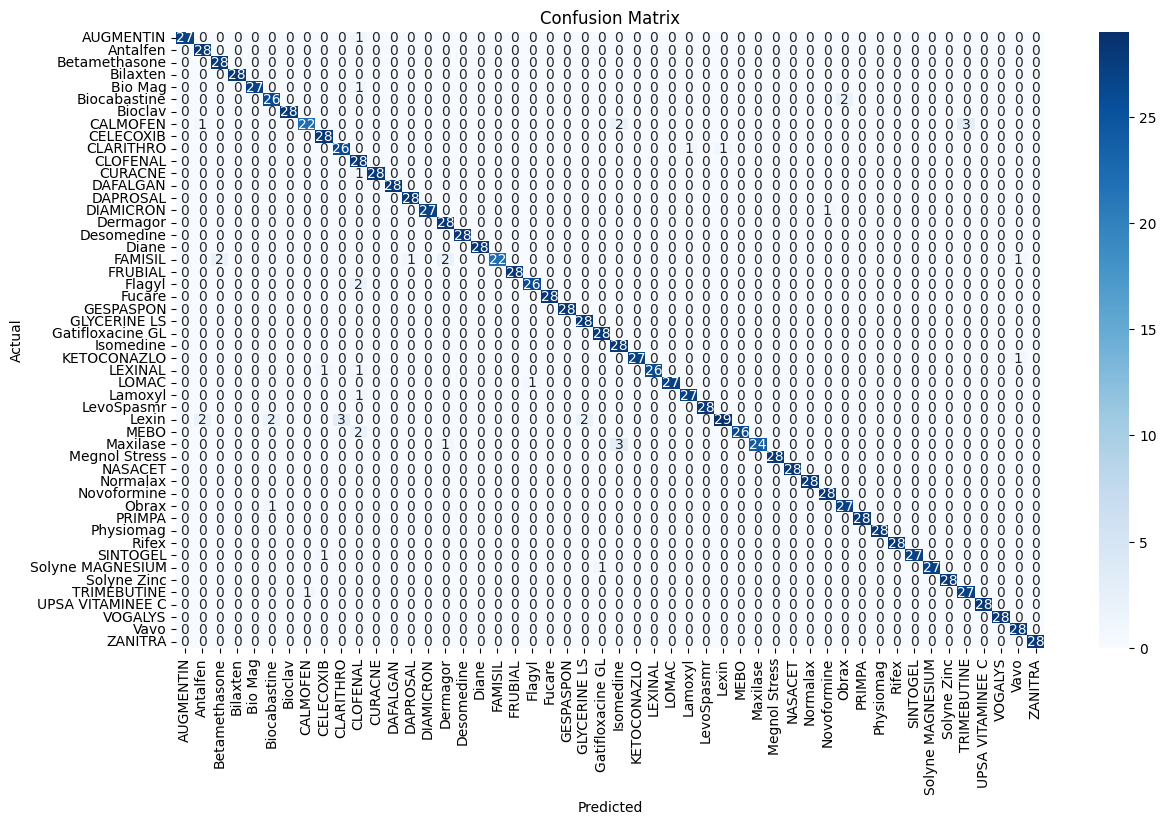

Classification Report:
                  precision    recall  f1-score   support

       AUGMENTIN       1.00      0.96      0.98        28
        Antalfen       0.90      1.00      0.95        28
   Betamethasone       0.93      1.00      0.97        28
        Bilaxten       1.00      1.00      1.00        28
         Bio Mag       1.00      0.96      0.98        28
    Biocabastine       0.90      0.93      0.91        28
         Bioclav       1.00      1.00      1.00        28
        CALMOFEN       0.96      0.79      0.86        28
       CELECOXIB       0.93      1.00      0.97        28
       CLARITHRO       0.90      0.93      0.91        28
        CLOFENAL       0.76      1.00      0.86        28
         CURACNE       1.00      0.97      0.98        29
        DAFALGAN       1.00      1.00      1.00        28
        DAPROSAL       0.97      1.00      0.98        28
       DIAMICRON       1.00      0.96      0.98        28
        Dermagor       0.90      1.00      0.95 

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
val_probs = knn.predict_proba(val_data)


acc = accuracy_score(val_labels, val_predictions)
print(f"Accuracy: {acc*100:.2f}%")


loss = log_loss(val_labels, val_probs)
print(f"Log Loss: {loss:.4f}")


cm = confusion_matrix(val_labels, val_predictions)


plt.figure(figsize=(14,8))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues',
            xticklabels=[class_names[i] for i in range(len(class_names))],
            yticklabels=[class_names[i] for i in range(len(class_names))])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(val_labels, val_predictions, target_names=class_names))

تم العثور على 50 فئات.
فئة 'AUGMENTIN' تحتوي على 112 صورة.
فئة 'Antalfen' تحتوي على 112 صورة.
فئة 'Betamethasone' تحتوي على 112 صورة.
فئة 'Bilaxten' تحتوي على 112 صورة.
فئة 'Bio Mag' تحتوي على 112 صورة.
فئة 'Biocabastine' تحتوي على 112 صورة.
فئة 'Bioclav' تحتوي على 112 صورة.
فئة 'CALMOFEN' تحتوي على 112 صورة.
فئة 'CELECOXIB' تحتوي على 112 صورة.
فئة 'CLARITHRO' تحتوي على 112 صورة.
فئة 'CLOFENAL' تحتوي على 112 صورة.
فئة 'CURACNE' تحتوي على 116 صورة.
فئة 'DAFALGAN' تحتوي على 112 صورة.
فئة 'DAPROSAL' تحتوي على 112 صورة.
فئة 'DIAMICRON' تحتوي على 112 صورة.
فئة 'Dermagor' تحتوي على 112 صورة.
فئة 'Desomedine' تحتوي على 112 صورة.
فئة 'Diane' تحتوي على 112 صورة.
فئة 'FAMISIL' تحتوي على 112 صورة.
فئة 'FRUBIAL' تحتوي على 112 صورة.
فئة 'Flagyl' تحتوي على 112 صورة.
فئة 'Fucare' تحتوي على 112 صورة.
فئة 'GESPASPON' تحتوي على 112 صورة.
فئة 'GLYCERINE LS' تحتوي على 112 صورة.
فئة 'Gatifloxacine GL' تحتوي على 112 صورة.
فئة 'Isomedine' تحتوي على 112 صورة.
فئة 'KETOCONAZLO' تحتوي على 112 صورة.
فئة 'LEXINAL

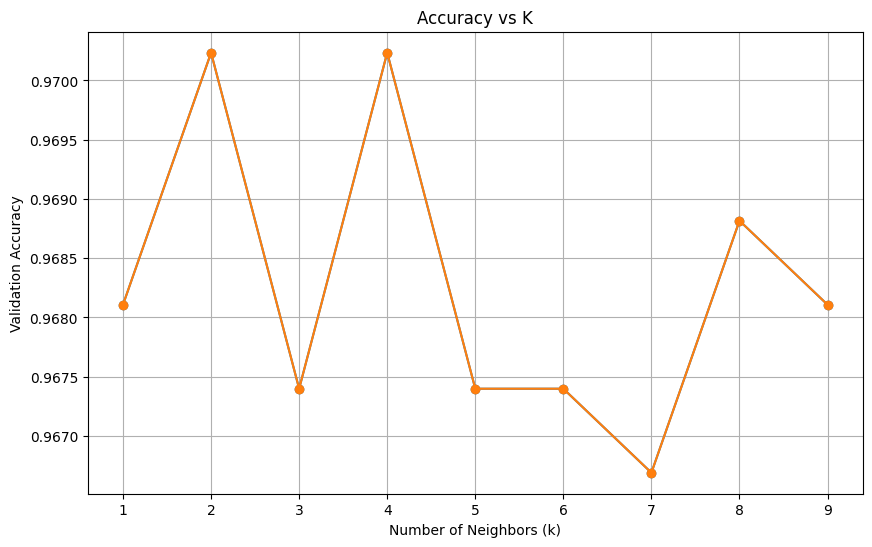

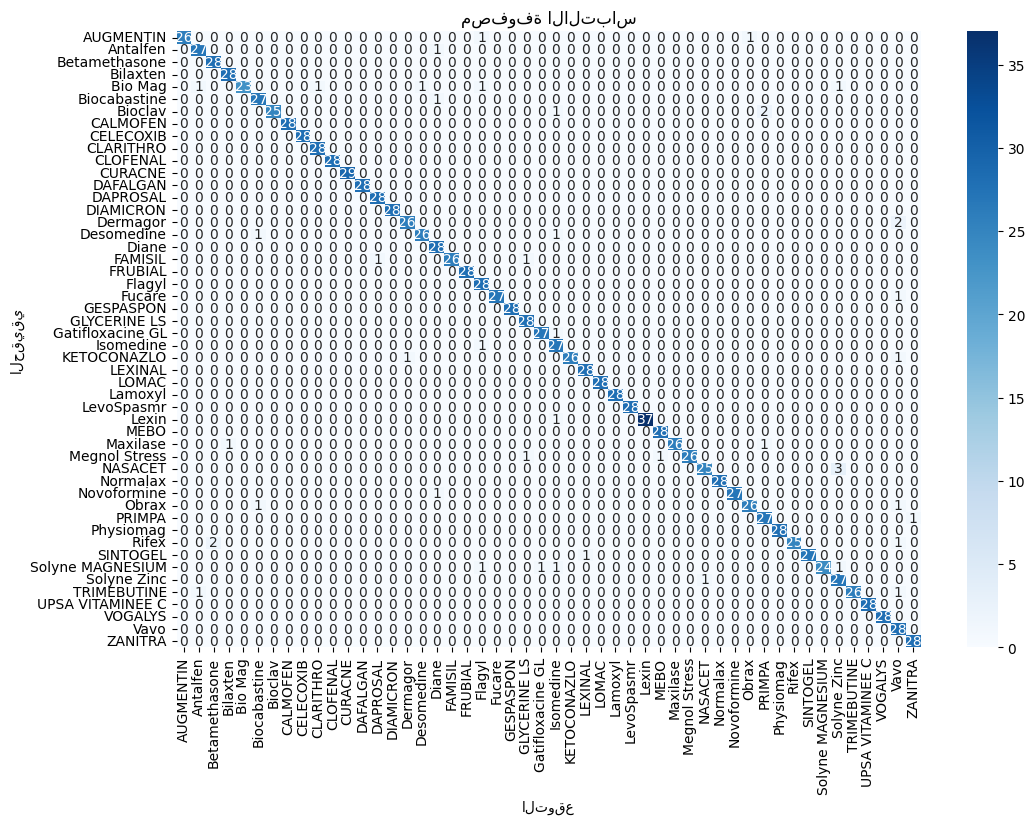

In [ ]:
import os
import cv2
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns


def apply_gabor(img):
    g_kernel = cv2.getGaborKernel((21, 21), 8.0, np.pi/4, 10.0, 0.5, 0, ktype=cv2.CV_32F)
    filtered_img = cv2.filter2D(img, cv2.CV_8UC3, g_kernel)
    return filtered_img

def apply_dog(img):
    blur1 = cv2.GaussianBlur(img, (5, 5), 1)
    blur2 = cv2.GaussianBlur(img, (5, 5), 2)
    dog = cv2.subtract(blur1, blur2)
    return dog


def load_and_process_images(base_path):
    data = []
    labels = []
    class_names = sorted([folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))])

    print(f" {len(class_names)} ")

    for idx, class_folder in enumerate(class_names):
        class_path = os.path.join(base_path, class_folder)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"'{class_folder}' {len(image_files)} ")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (128, 128))


            dog_img = apply_dog(img)
            gabor_img = apply_gabor(dog_img)


            data.append(gabor_img.flatten())
            labels.append(idx)

    return np.array(data), np.array(labels), class_names


train_path = '/content/drive/MyDrive/KAdata/train'
val_path = '/content/drive/MyDrive/KAdata/validation'

train_data, train_labels, class_names = load_and_process_images(train_path)
val_data, val_labels, _ = load_and_process_images(val_path)

print(f"حجم بيانات التدريب: {len(train_data)}")
print(f"حجم بيانات التحقق: {len(val_data)}")


lda = LinearDiscriminantAnalysis(n_components=min(len(np.unique(train_labels))-1, 50))
train_data_lda = lda.fit_transform(train_data, train_labels)
val_data_lda = lda.transform(val_data)


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(train_data_lda, train_labels)

val_predictions = knn.predict(val_data_lda)
val_probabilities = knn.predict_proba(val_data_lda)


acc = accuracy_score(val_labels, val_predictions)
print(f"\nدقة النموذج: {acc * 100:.2f}%")
loss = log_loss(val_labels, val_probabilities)
print(f"قيمة الخسارة (Log Loss): {loss:.4f}")

print("\nتقرير التصنيف:")
from sklearn.utils.multiclass import unique_labels
unique_val_labels = unique_labels(val_labels)
print(classification_report(val_labels, val_predictions, labels=unique_val_labels,
                            target_names=[class_names[i] for i in unique_val_labels]))

accuracies = []
base_K_values = [4]

plt.figure(figsize=(10, 6))

for base_k in base_K_values:
    accuracies = []


    for k in ks:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_data_lda, train_labels)
        preds = knn.predict(val_data_lda)
        acc = accuracy_score(val_labels, preds)
        accuracies.append(acc)


    plt.plot(ks, accuracies, marker='o', label=f"K={base_k} input")

plt.plot(ks, accuracies, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.show()

# رسم مصفوفة الالتباس
cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[class_names[i] for i in unique_val_labels],
            yticklabels=[class_names[i] for i in unique_val_labels])
plt.xlabel("التوقع")
plt.ylabel("الحقيقي")
plt.title("مصفوفة الالتباس")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog


def load_and_extract_features(base_path):
    data = []
    labels = []
    class_names = sorted([folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))])

    print(f"تم العثور على {len(class_names)} فئة.")

    for idx, class_folder in enumerate(class_names):
        class_path = os.path.join(base_path, class_folder)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"فئة '{class_folder}' تحتوي على {len(image_files)} صورة.")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (128, 128))

            features = hog(gray, orientations=6, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys')

            data.append(features)
            labels.append(idx)

    return np.array(data), np.array(labels), class_names


train_path = '/content/drive/MyDrive/KAdata/train'
val_path = '/content/drive/MyDrive/KAdata/validation'


train_data, train_labels, class_names = load_and_extract_features(train_path)
val_data, val_labels, _ = load_and_extract_features(val_path)

print(f"\nحجم بيانات التدريب: {train_data.shape}")
print(f"حجم بيانات التحقق: {val_data.shape}")


pca = PCA(n_components=50)
train_data_pca = pca.fit_transform(train_data)
val_data_pca = pca.transform(val_data)



svm = SVC(kernel='rbf', C=1, gamma='auto')
svm.fit(train_data_pca, train_labels)



val_predictions = svm.predict(val_data_pca)


accuracy = accuracy_score(val_labels, val_predictions)
print(f"\nج: {accuracy * 100:.2f}%")


print("\nف:")
print(classification_report(val_labels, val_predictions, target_names=[class_names[i] for i in np.unique(val_labels)]))

cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in np.unique(val_labels)],
            yticklabels=[class_names[i] for i in np.unique(val_labels)])
plt.xlabel("التوقع")
plt.ylabel("الحقيقي")
plt.title("مصفوفة الالتباس")
plt.show()


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 79)

تم العثور على 50 فئة.
فئة 'AUGMENTIN' تحتوي على 112 صورة.
فئة 'Antalfen' تحتوي على 112 صورة.
فئة 'Betamethasone' تحتوي على 112 صورة.
فئة 'Bilaxten' تحتوي على 112 صورة.
فئة 'Bio Mag' تحتوي على 112 صورة.
فئة 'Biocabastine' تحتوي على 112 صورة.
فئة 'Bioclav' تحتوي على 112 صورة.
فئة 'CALMOFEN' تحتوي على 112 صورة.
فئة 'CELECOXIB' تحتوي على 112 صورة.
فئة 'CLARITHRO' تحتوي على 112 صورة.
فئة 'CLOFENAL' تحتوي على 112 صورة.
فئة 'CURACNE' تحتوي على 116 صورة.
فئة 'DAFALGAN' تحتوي على 112 صورة.
فئة 'DAPROSAL' تحتوي على 112 صورة.
فئة 'DIAMICRON' تحتوي على 112 صورة.
فئة 'Dermagor' تحتوي على 112 صورة.
فئة 'Desomedine' تحتوي على 112 صورة.
فئة 'Diane' تحتوي على 112 صورة.
فئة 'FAMISIL' تحتوي على 112 صورة.
فئة 'FRUBIAL' تحتوي على 112 صورة.
فئة 'Flagyl' تحتوي على 112 صورة.
فئة 'Fucare' تحتوي على 112 صورة.
فئة 'GESPASPON' تحتوي على 112 صورة.
فئة 'GLYCERINE LS' تحتوي على 112 صورة.
فئة 'Gatifloxacine GL' تحتوي على 112 صورة.
فئة 'Isomedine' تحتوي على 112 صورة.
فئة 'KETOCONAZLO' تحتوي على 112 صورة.
فئة 'LEXINAL'

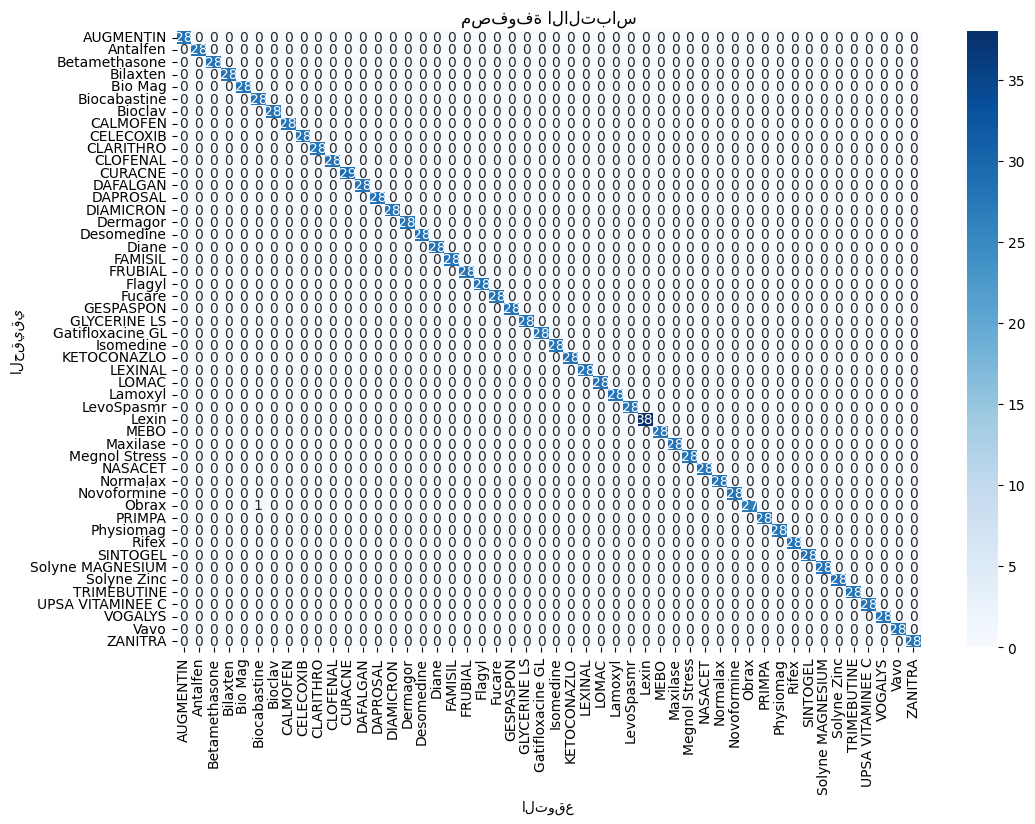

In [ ]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog

def load_and_extract_features(base_path, add_noise=False):
    data = []
    labels = []
    class_names = sorted([folder for folder in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, folder))])

    print(f"تم العثور على {len(class_names)} فئة.")

    for idx, class_folder in enumerate(class_names):
        class_path = os.path.join(base_path, class_folder)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

        print(f"فئة '{class_folder}' تحتوي على {len(image_files)} صورة.")

        for img_name in image_files:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            gray = cv2.resize(gray, (128, 128))

            # إضافة الضوضاء إذا تم التفعيل
            if add_noise:
                gray = gray.astype(np.float32)
                noise = np.random.normal(0, 10, gray.shape).astype(np.float32)
                gray = np.clip(gray + noise, 0, 255).astype(np.uint8)

            features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), block_norm='L2-Hys')

            data.append(features)
            labels.append(idx)

    return np.array(data), np.array(labels), class_names

train_path = '/content/drive/MyDrive/KAdata/train'
val_path = '/content/drive/MyDrive/KAdata/validation'


train_data, train_labels, class_names = load_and_extract_features(train_path, add_noise=True)
val_data, val_labels, _ = load_and_extract_features(val_path, add_noise=True)

print(f"n{train_data.shape}")
print(f" {val_data.shape}")


pca = PCA(n_components=100)
train_data_pca = pca.fit_transform(train_data)
val_data_pca = pca.transform(val_data)


svm = SVC(kernel='rbf', C=8, gamma='auto')
svm.fit(train_data_pca, train_labels)


val_predictions = svm.predict(val_data_pca)


accuracy = accuracy_score(val_labels, val_predictions)
print(f"\nدقة النموذج: {accuracy * 100:.2f}%")

print("\nتقرير التصنيف:")
print(classification_report(val_labels, val_predictions, target_names=[class_names[i] for i in np.unique(val_labels)]))


cm = confusion_matrix(val_labels, val_predictions)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in np.unique(val_labels)],
            yticklabels=[class_names[i] for i in np.unique(val_labels)])
plt.xlabel("التوقع")
plt.ylabel("الحقيقي")
plt.title("مصفوفة الالتباس")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from PIL import Image
from torchvision import transforms


def build_gabor_kernels(scales=4, orientations=6):
    kernels = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        for sigma in (1, 2):
            for lamda in np.linspace(np.pi/4, np.pi, scales):
                kernel = cv2.getGaborKernel((21, 21), sigma, theta, lamda, 0.5, 0, ktype=cv2.CV_32F)
                kernels.append(kernel)
    return kernels


def extract_gabor_features(image, kernels):
    feats = []
    for k in kernels:
        f = cv2.filter2D(image, cv2.CV_8UC3, k)
        feats.append(f.mean())
        feats.append(f.std())
    return feats


augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomResizedCrop((128, 128), scale=(0.8, 1.0))
])

def load_dataset_with_gabor(data_dir, augment_images=False, augment_factor=2):
    X, y = [], []
    kernels = build_gabor_kernels()
    classes = sorted(os.listdir(data_dir))

    for label in classes:
        class_dir = os.path.join(data_dir, label)
        for filename in os.listdir(class_dir):
            path = os.path.join(class_dir, filename)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (128, 128))
            features = extract_gabor_features(img, kernels)
            X.append(features)
            y.append(label)


    return np.array(X), np.array(y), classes

train_path = "/content/drive/MyDrive/KAdata/train"
val_path = "/content/drive/MyDrive/KAdata/validation"


X_train, y_train, classes = load_dataset_with_gabor(train_path, augment_images=True, augment_factor=2)
X_val, y_val, _ = load_dataset_with_gabor(val_path, augment_images=False)


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)


pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train_pca, y_train_enc)


y_pred = svm.predict(X_val_pca)
print("📊 تقرير التصنيف:\n", classification_report(y_val_enc, y_pred, target_names=le.classes_))
print("🎯 الدقة:", accuracy_score(y_val_enc, y_pred))


📊 تقرير التصنيف:
                   precision    recall  f1-score   support

       AUGMENTIN       1.00      1.00      1.00        28
        Antalfen       1.00      1.00      1.00        28
   Betamethasone       1.00      1.00      1.00        28
        Bilaxten       1.00      0.93      0.96        28
         Bio Mag       1.00      1.00      1.00        28
    Biocabastine       0.97      1.00      0.98        28
         Bioclav       1.00      1.00      1.00        28
        CALMOFEN       1.00      1.00      1.00        28
       CELECOXIB       1.00      1.00      1.00        28
       CLARITHRO       1.00      1.00      1.00        28
        CLOFENAL       1.00      1.00      1.00        28
         CURACNE       1.00      1.00      1.00        29
        DAFALGAN       1.00      1.00      1.00        28
        DAPROSAL       1.00      1.00      1.00        28
       DIAMICRON       1.00      1.00      1.00        28
        Dermagor       1.00      0.96      0.98      

🎯 الدقة (Accuracy): 0.9943
📌 Precision: 0.9946
📌 Recall: 0.9943
📌 F1 Score: 0.9943

📊 مصفوفة الالتباس (confusion matrix):
 [[28  0  0 ...  0  0  0]
 [ 0 28  0 ...  0  0  0]
 [ 0  0 28 ...  0  0  0]
 ...
 [ 0  0  0 ... 28  0  0]
 [ 0  0  0 ...  0 28  0]
 [ 0  0  0 ...  0  0 28]]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


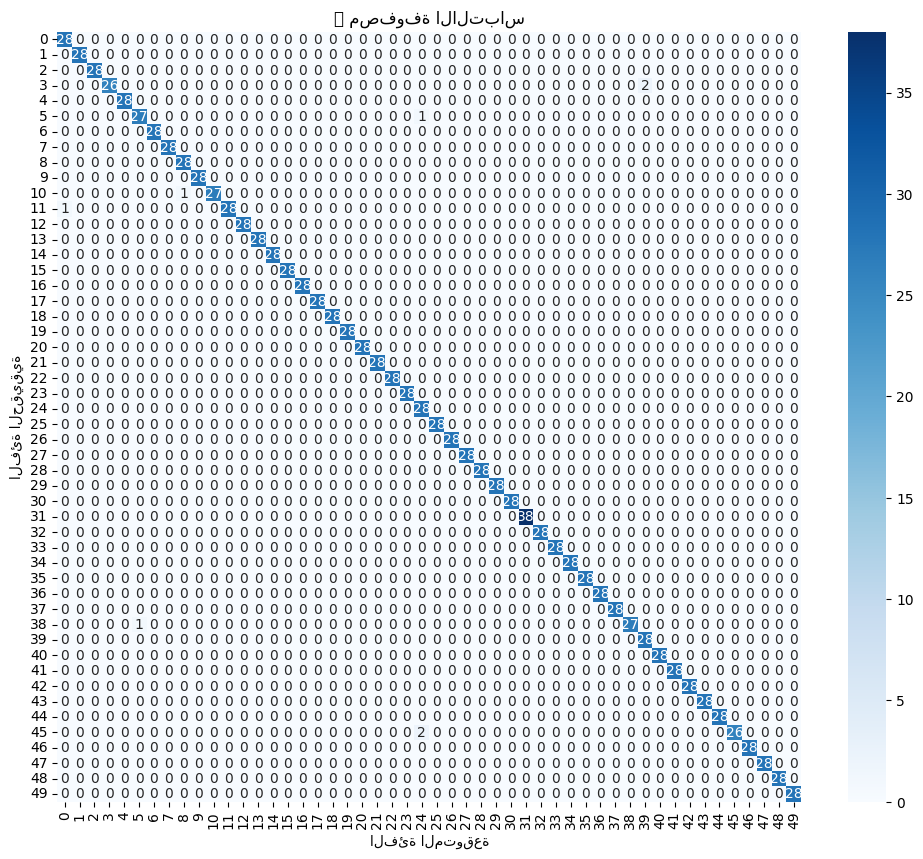

<ipython-input-6-1ce168373073>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="crest")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


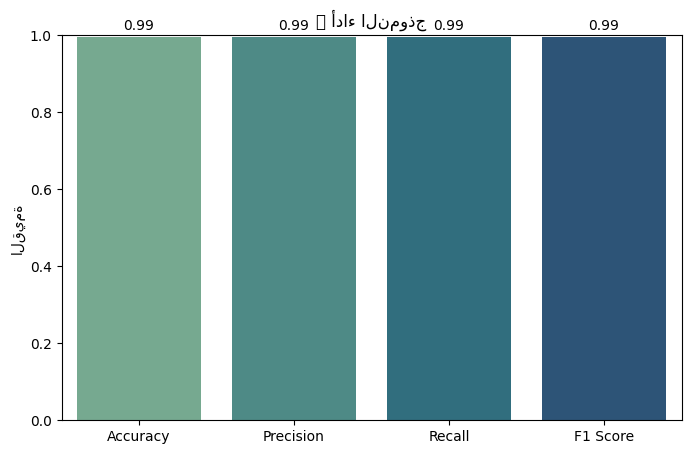

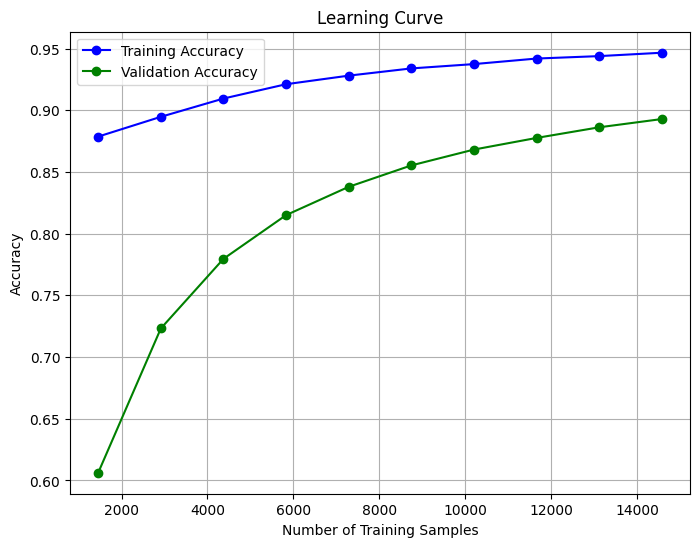

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.model_selection import learning_curve


accuracy = accuracy_score(y_val_enc, y_pred)
precision = precision_score(y_val_enc, y_pred, average='macro')
recall = recall_score(y_val_enc, y_pred, average='macro')
f1 = f1_score(y_val_enc, y_pred, average='macro')

print("🎯 (Accuracy):", round(accuracy, 4))
print("📌 Precision:", round(precision, 4))
print("📌 Recall:", round(recall, 4))
print("📌 F1 Score:", round(f1, 4))


cm = confusion_matrix(y_val_enc, y_pred)
print("\n(confusion matrix):\n", cm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()


metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette="crest")
plt.ylim(0, 1)
plt.title("")
plt.ylabel("")
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()


train_sizes, train_scores, test_scores = learning_curve(
    svm, np.concatenate((X_train_pca, X_val_pca)),
    np.concatenate((y_train_enc, y_val_enc)),
    cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
)

train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='blue',  label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Validation Accuracy')
plt.title("Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()
